# 02 · 休市期间的价格发现：代币能预测开盘跳空吗？

**研究问题**：美股休市时，代币化股票仍在链上 24 小时交易。休市期间代币价格的变化，能否预测下一次开盘时股价的跳空？

**核心回归**：

$$\text{Gap}_{i,t} = \alpha + \beta \cdot \text{TokenRet}_{i,t} + \varepsilon_{i,t}$$

- $\text{Gap}_{i,t}$：股票 $i$ 的开盘跳空 = 开盘价 ÷ 上一交易日收盘价 − 1
- $\text{TokenRet}_{i,t}$：同一段休市期间，代币价格的涨跌幅
- 如果 $\beta$ 显著为正、$R^2$ 较高，说明代币在休市期间**提前反映了信息**

**重要细节**：美股"收盘"后并非完全不交易——有盘后（16:00–20:00）、盘前（4:00–9:30），工作日夜间还有 Blue Ocean 等 24 小时交易平台。
所以只有**周末（纽约时间周五 20:00 到周日 20:00）** 是美股真正完全不交易的时段。我们用这个"纯周末窗口"做主检验。

> 数据：`data/history/`，由 `analysis/backfill.py` 生成（代币约 6 个月的每小时价格 + 股票日线）。

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import patsy
from scipy import stats

pd.set_option("display.width", 140)
plt.rcParams.update({
    "font.sans-serif": ["Microsoft YaHei", "SimHei", "DejaVu Sans"], "axes.unicode_minus": False,
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e1e0d9", "grid.linewidth": 0.8,
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": "#52514e",
    "xtick.color": "#898781", "ytick.color": "#898781",
})
BLUE, ORANGE, MUTED = "#2a78d6", "#eb6834", "#898781"
ET = "America/New_York"
H = Path.cwd().parent / "data" / "history"

## 1. 读取历史数据

In [2]:
tok = pd.read_csv(H / "token_hourly.csv", parse_dates=["ts_utc"])
daily = pd.read_csv(H / "stock_daily.csv", parse_dates=["ts_utc", "date"])

print(f"代币小时线：{len(tok):,} 行，{tok.pair_address.nunique()} 个池子，{tok.ticker.nunique()} 只股票")
print(f"时间范围：{tok.ts_utc.min():%Y-%m-%d} 到 {tok.ts_utc.max():%Y-%m-%d}")
tok.groupby("ticker").agg(池子数=("pair_address", "nunique"), 小时数=("ts_utc", "nunique"),
                          最早=("ts_utc", "min")).sort_values("小时数")

代币小时线：104,587 行，38 个池子，11 只股票
时间范围：2026-02-27 到 2026-10-03


,池子数,小时数,最早
ticker,,,
COIN,2,1848,2026-06-18 18:00:00+00:00
HOOD,3,1965,2026-06-12 18:00:00+00:00
META,4,2163,2026-06-23 02:00:00+00:00
AMZN,1,3994,2026-03-15 22:00:00+00:00
AAPL,2,3997,2026-03-26 00:00:00+00:00
GOOGL,4,4498,2026-03-26 21:00:00+00:00
MSTR,2,5122,2026-03-03 16:00:00+00:00
SPY,6,5174,2026-03-02 02:00:00+00:00
NVDA,7,5192,2026-03-01 09:00:00+00:00


## 2. 构造每只股票的"代币价格指数"
同一只股票往往有多个交易池。每个小时，用**成交额加权**的收盘价作为这只股票代币的价格（没有成交的池子不参与）。

K 线的时间戳是这一小时的**开始**时刻，所以价格对应的是这一小时**结束**时的价格。

In [3]:
t = tok[tok.volume_usd > 0].copy()
t["end_utc"] = t.ts_utc + pd.Timedelta(hours=1)
t["w"] = t.close * t.volume_usd
idx = (t.groupby(["ticker", "end_utc"])
         .agg(w=("w", "sum"), v=("volume_usd", "sum"), pools=("pair_address", "nunique"))
         .reset_index())
idx["price"] = idx.w / idx.v
idx = idx[["ticker", "end_utc", "price", "v", "pools"]].sort_values(["end_utc", "ticker"])
idx.head()

,ticker,end_utc,price,v,pools
28779,QQQ,2026-02-27 01:00:00+00:00,606.865617,3074.931254,1
28780,QQQ,2026-02-27 02:00:00+00:00,607.014161,1902.458834,1
28781,QQQ,2026-02-27 03:00:00+00:00,607.551069,6864.602279,1
28782,QQQ,2026-02-27 04:00:00+00:00,610.827001,42566.395317,1
28783,QQQ,2026-02-27 05:00:00+00:00,611.626579,3369.834394,1


## 3. 找出每一次休市，计算跳空和代币涨跌
相邻两个交易日 $d_0$、$d_1$ 之间就是一次休市：

| 窗口 | 起点（纽约时间） | 终点（纽约时间） | 说明 |
|---|---|---|---|
| **收盘→开盘** | $d_0$ 16:00 | $d_1$ 9:00 | 包含盘后、盘前交易，代币可能只是在"跟随"美股 |
| **纯周末** | 周五 20:00 | 周日 20:00 | 美股完全不交易，最干净的检验 |

代币价格取"不晚于该时刻的最近一个整点"的价格；如果最近一次成交超过 3 小时之前，视为缺失。

In [4]:
TOL = pd.Timedelta(hours=3)

def token_price_at(tickers, times):
    # 每个 (股票, 时刻) 取不晚于该时刻的最近一次代币价格
    q = pd.DataFrame({"ticker": np.asarray(tickers), "at": pd.to_datetime(np.asarray(times), utc=True)})
    q["pos"] = np.arange(len(q))   # 记住原来的行位置，合并后按位置排回去
    m = pd.merge_asof(q.sort_values("at"), idx.rename(columns={"end_utc": "at"}), on="at", by="ticker",
                      direction="backward", tolerance=TOL)
    return m.sort_values("pos").price.to_numpy()

def at_et(dates, hour, minute=0, day_offset=0):
    d = pd.to_datetime(dates) + pd.Timedelta(days=day_offset)
    return (d + pd.Timedelta(hours=hour, minutes=minute)).dt.tz_localize(ET).dt.tz_convert("UTC")

d = daily.sort_values(["ticker", "date"]).copy()
d["next_date"] = d.groupby("ticker").date.shift(-1)
d["next_open"] = d.groupby("ticker").open.shift(-1)
ev = d.dropna(subset=["next_date"]).rename(columns={"date": "d0", "next_date": "d1", "close": "close0", "next_open": "open1"})
ev["days"] = (ev.d1 - ev.d0).dt.days
ev["kind"] = np.select([ev.days == 1, (ev.days == 3) & (ev.d0.dt.dayofweek == 4)],
                       ["工作日隔夜", "周末"], "节假日")
ev["gap"] = (ev.open1 / ev.close0 - 1) * 100

# 窗口一：收盘 -> 开盘前（用 9:00 的价格，避免混入开盘后的信息）
ev["tok_close"] = token_price_at(ev.ticker, at_et(ev.d0, 16))
ev["tok_preopen"] = token_price_at(ev.ticker, at_et(ev.d1, 9))
ev["tokret_c2o"] = (ev.tok_preopen / ev.tok_close - 1) * 100

# 窗口二：纯周末，周五 20:00 -> 周日 20:00
wk = ev.kind == "周末"
ev.loc[wk, "tok_fri20"] = token_price_at(ev.ticker[wk], at_et(ev.d0[wk], 20))
ev.loc[wk, "tok_sun20"] = token_price_at(ev.ticker[wk], at_et(ev.d0[wk], 20, day_offset=2))
ev["tokret_wkend"] = (ev.tok_sun20 / ev.tok_fri20 - 1) * 100

ev = ev.dropna(subset=["tokret_c2o"])

# 自检：事件只能落在有代币数据的股票和日期范围内，否则说明价格匹配出了错
assert set(ev.ticker) <= set(idx.ticker), "出现了没有代币数据的股票"
assert ev.d0.min() >= idx.end_utc.min().tz_convert(None).normalize() - pd.Timedelta(days=1), "事件早于代币数据"
# 清洗：收盘时代币价格和股价应该很接近；偏离超过 5% 基本是零星的异常成交，剔除
bad = (ev.tok_close / ev.close0 - 1).abs() >= 0.05
print(f"剔除价格明显异常的事件 {bad.sum()} 个：")
print(ev.loc[bad, ["ticker", "d0", "close0", "tok_close"]].to_string(index=False))
assert bad.mean() < 0.01, "异常事件超过 1%，可能是系统性的匹配错误，需要检查"
ev = ev[~bad]

print(f"有效休市事件：{len(ev):,} 个，时间 {ev.d0.min():%Y-%m-%d} 到 {ev.d1.max():%Y-%m-%d}")
print(ev.kind.value_counts().to_string())
print(f"其中纯周末窗口有数据的：{ev.tokret_wkend.notna().sum()} 个")

剔除价格明显异常的事件 1 个：
ticker         d0     close0  tok_close
 GOOGL 2026-07-27 326.559998 290.810961
有效休市事件：1,362 个，时间 2026-02-27 到 2026-10-02
kind
工作日隔夜    1085
周末        229
节假日        48
其中纯周末窗口有数据的：225 个


## 4. 先看图
每个点是一次休市（某只股票）。横轴是代币在休市期间的涨跌，纵轴是开盘跳空。
如果代币完美预测跳空，点会落在 45° 虚线上。

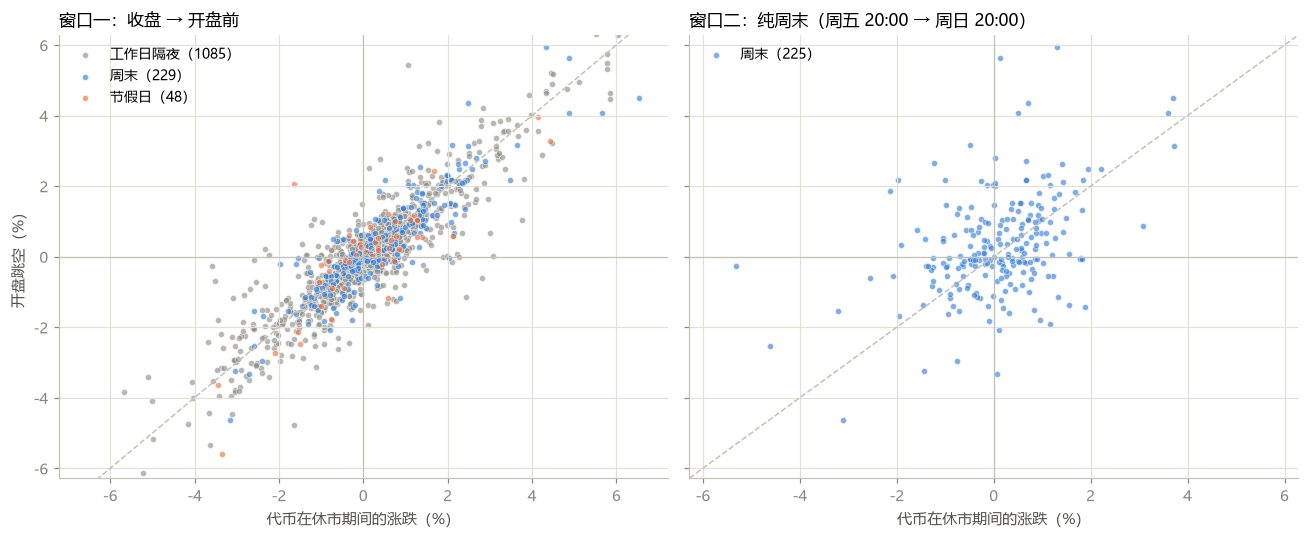

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
panels = [("tokret_c2o", "窗口一：收盘 → 开盘前", ev),
          ("tokret_wkend", "窗口二：纯周末（周五 20:00 → 周日 20:00）", ev[ev.tokret_wkend.notna()])]
for ax, (col, title, data) in zip(axes, panels):
    for kind, color in [("工作日隔夜", MUTED), ("周末", BLUE), ("节假日", ORANGE)]:
        s = data[data.kind == kind]
        if len(s):
            ax.scatter(s[col], s.gap, s=16, alpha=0.6, color=color, edgecolors="white", linewidths=0.5,
                       label=f"{kind}（{len(s)}）")
    lim = np.nanpercentile(np.abs(np.r_[data[col], data.gap]), 99) * 1.1
    ax.plot([-lim, lim], [-lim, lim], color="#c3c2b7", linestyle="--", linewidth=1)
    ax.axhline(0, color="#c3c2b7", linewidth=0.8); ax.axvline(0, color="#c3c2b7", linewidth=0.8)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.set_title(title, loc="left", fontsize=11)
    ax.set_xlabel("代币在休市期间的涨跌（%）")
    ax.legend(frameon=False, fontsize=9, loc="upper left")
axes[0].set_ylabel("开盘跳空（%）")
plt.tight_layout()
plt.show()

## 5. 回归
- 同一天的跳空在不同股票之间高度相关（比如整个市场一起高开），所以标准误**按日期聚类**（cluster by $d_1$）
- 除了检验 $\beta = 0$（有没有预测力），也检验 $\beta = 1$（是不是一比一地反映）

In [6]:
def reg(data, x, label):
    data = data.dropna(subset=[x, "gap"])
    m = smf.ols(f"gap ~ {x}", data=data).fit(cov_type="cluster", cov_kwds={"groups": data.d1.astype(str)})
    b, se = m.params[x], m.bse[x]
    return pd.Series({"样本": label, "N": int(m.nobs), "休市次数": data.d1.nunique(),
                      "β": b, "标准误": se, "t(β=0)": b / se, "t(β=1)": (b - 1) / se,
                      "R²": m.rsquared}), m

results, models = [], {}
for label, data, x in [
    ("全部休市 · 收盘→开盘", ev, "tokret_c2o"),
    ("工作日隔夜 · 收盘→开盘", ev[ev.kind == "工作日隔夜"], "tokret_c2o"),
    ("周末 · 收盘→开盘", ev[ev.kind == "周末"], "tokret_c2o"),
    ("周末 · 纯周末窗口", ev[ev.kind == "周末"], "tokret_wkend"),
]:
    r, m = reg(data, x, label)
    results.append(r); models[label] = m
table = pd.DataFrame(results).set_index("样本")
table.round(3)

,N,休市次数,β,标准误,t(β=0),t(β=1),R²
样本,,,,,,,
全部休市 · 收盘→开盘,1362,150,0.950,0.021,46.117,-2.402,0.838
工作日隔夜 · 收盘→开盘,1085,119,0.955,0.023,41.124,-1.957,0.842
周末 · 收盘→开盘,229,26,0.936,0.052,18.134,-1.232,0.838
周末 · 纯周末窗口,225,26,0.596,0.145,4.114,-2.789,0.197


**怎么读这张表**
- **β**：代币涨 1%，开盘跳空平均多少 %
- **t(β=0)**：绝对值大于约 2 → 在 5% 水平上显著，代币有预测力
- **t(β=1)**：绝对值小于约 2 → 不能拒绝"一比一反映"
- **R²**：跳空的变化中，有多大比例能被代币解释
- **最关键的是最后一行（纯周末窗口）**：这时美股完全不交易，如果仍然显著，才能说代币在做"价格发现"，而不是跟随盘前交易

In [7]:
print(models["周末 · 纯周末窗口"].summary().tables[1])

                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        0.2713      0.176      1.546      0.122      -0.073       0.615
tokret_wkend     0.5960      0.145      4.114      0.000       0.312       0.880


## 6. 控制共同因素：比特币和大盘
周末很多股票的代币会**一起**涨跌。代币里的信息可能只是：

- **比特币的周末波动**：加密市场整体情绪，尤其影响 MSTR、COIN、HOOD
- **大盘的周末波动**：用 SPY 代币的周末涨跌衡量整体市场情绪

如果加入这两个控制变量后，代币自身的 $\beta$ 仍然显著，说明代币包含了**这只股票特有的信息**，而不只是共同波动。

$$\text{Gap}_{i,t} = \alpha + \beta_1 \text{TokenRet}_{i,t} + \beta_2 \text{BTCRet}_t + \beta_3 \text{MktRet}_t + \varepsilon_{i,t}$$

（加入大盘控制时去掉 SPY 和 QQQ 自己，因为它们本身就是"大盘"。）

In [8]:
btc = pd.read_csv(H / "btc_hourly.csv", parse_dates=["ts_utc"])
btc_idx = pd.DataFrame({"at": btc.ts_utc + pd.Timedelta(hours=1), "price": btc.close}).sort_values("at")

def btc_price_at(times):
    q = pd.DataFrame({"at": pd.to_datetime(np.asarray(times), utc=True)})
    q["pos"] = np.arange(len(q))
    m = pd.merge_asof(q.sort_values("at"), btc_idx, on="at", direction="backward", tolerance=TOL)
    return m.sort_values("pos").price.to_numpy()

w = ev[(ev.kind == "周末") & ev.tokret_wkend.notna()].copy()
w["btcret"] = (btc_price_at(at_et(w.d0, 20, day_offset=2)) / btc_price_at(at_et(w.d0, 20)) - 1) * 100
mkt = w[w.ticker == "SPY"].set_index("d0").tokret_wkend.rename("mktret")
w = w.join(mkt, on="d0")
w["crypto"] = w.ticker.isin(["MSTR", "COIN", "HOOD"]).astype(int)

print(f"周末样本：{len(w)} 个，比特币数据缺失 {w.btcret.isna().sum()} 个，大盘数据缺失 {w.mktret.isna().sum()} 个")
print("\n解释变量之间的相关系数（相关性越高，越难分开各自的作用）：")
print(w[["tokret_wkend", "btcret", "mktret"]].corr().round(2).to_string())

周末样本：225 个，比特币数据缺失 0 个，大盘数据缺失 2 个

解释变量之间的相关系数（相关性越高，越难分开各自的作用）：
              tokret_wkend  btcret  mktret
tokret_wkend          1.00    0.57    0.57
btcret                0.57    1.00    0.54
mktret                0.57    0.54    1.00


In [9]:
def fit(formula, data):
    data = data.dropna(subset=[c for c in ["gap", "tokret_wkend", "btcret", "mktret"] if c in formula])
    return smf.ols(formula, data=data).fit(cov_type="cluster", cov_kwds={"groups": data.d1.astype(str)})

no_mkt = w[~w.ticker.isin(["SPY", "QQQ"])]
specs = {
    "(1) 只有代币":           ("gap ~ tokret_wkend", no_mkt),
    "(2) 只有比特币":         ("gap ~ btcret", no_mkt),
    "(3) 代币 + 比特币":      ("gap ~ tokret_wkend + btcret", no_mkt),
    "(4) 代币 + 比特币 + 大盘": ("gap ~ tokret_wkend + btcret + mktret", no_mkt),
    "(5) 加密相关股票交互":     ("gap ~ tokret_wkend + btcret + btcret:crypto + mktret", no_mkt),
}
rows = {}
for name, (f, data) in specs.items():
    m = fit(f, data)
    r = {"N": int(m.nobs), "R²": m.rsquared}
    for var, label in [("tokret_wkend", "代币"), ("btcret", "比特币"), ("btcret:crypto", "比特币×加密股"), ("mktret", "大盘")]:
        if var in m.params:
            r[f"β {label}"] = m.params[var]
            r[f"t {label}"] = m.tvalues[var]
    rows[name] = r
ctrl = pd.DataFrame(rows).T
cols = ["N"] + [c for c in ctrl.columns if c.startswith(("β", "t "))] + ["R²"]
ctrl[cols].round(3)

,N,β 代币,t 代币,β 比特币,t 比特币,β 大盘,t 大盘,β 比特币×加密股,t 比特币×加密股,R²
(1) 只有代币,174.0,0.589,3.990,NaN,NaN,NaN,NaN,NaN,NaN,0.189
(2) 只有比特币,174.0,NaN,NaN,0.226,1.779,NaN,NaN,NaN,NaN,0.053
(3) 代币 + 比特币,174.0,0.621,4.712,-0.039,-0.340,NaN,NaN,NaN,NaN,0.190
(4) 代币 + 比特币 + 大盘,173.0,0.606,4.431,-0.025,-0.205,-0.022,-0.053,NaN,NaN,0.187
(5) 加密相关股票交互,173.0,0.513,3.526,-0.045,-0.413,0.040,0.095,0.219,0.82,0.194


**怎么读这张表**（重点看"β 代币"和它的 t 值）
- 对比 (1) 和 (3)、(4)：加入比特币和大盘后，代币的 β 如果变化不大且仍然显著（|t| > 2），说明代币包含了个股特有的信息
- (2)：比特币本身对周一跳空有多大解释力
- (5)：比特币的影响对 MSTR、COIN、HOOD 这类加密相关股票是否更强（看"β 比特币×加密股"）
- 所有回归都不含 SPY、QQQ，样本比第 5 节少一些

## 7. 稳健性检验：wild cluster bootstrap
**问题**：我们只有约 26 个周末（聚类）。聚类数少时，普通的聚类稳健标准误往往**偏小**，t 值被高估，容易得出"假显著"的结论。

**解决方法**：wild cluster bootstrap（Cameron, Gelbach & Miller, 2008），这是聚类数少时的标准做法。步骤：

1. 在**原假设成立**的条件下（比如 $\beta_{代币} = 0$）估计一个受约束的模型，得到拟合值和残差
2. 每次重抽样：给**每个周末**随机分配一个 +1 或 −1（Rademacher 权重），用它乘以这个周末所有观测的残差，构造新的 $y^*$。同一个周末的观测一起翻转，保留了周末内部的相关性
3. 用 $y^*$ 重新回归，算出 t 值 $t^*$
4. 重复 9,999 次。**bootstrap p 值 = $|t^*| \geq |t_{原始}|$ 的比例**

如果 bootstrap p 值仍然很小（< 0.05），就说明结论不是聚类数少造成的假象。

In [10]:
def cluster_t(X, y, groups, j):
    # OLS 加聚类稳健标准误（与 statsmodels 的默认小样本校正一致），返回第 j 个系数的 t 值
    XtX_inv = np.linalg.inv(X.T @ X)
    beta = XtX_inv @ X.T @ y
    u = y - X @ beta
    G, (N, K) = groups.max() + 1, X.shape
    scores = np.zeros((G, K))
    np.add.at(scores, groups, X * u[:, None])          # 每个聚类的 X'u 加总
    V = XtX_inv @ (scores.T @ scores) @ XtX_inv
    V *= G / (G - 1) * (N - 1) / (N - K)
    return beta[j], beta[j] / np.sqrt(V[j, j])

def wild_cluster_bootstrap(formula, data, var, null=0.0, B=9999, seed=42):
    data = data.dropna(subset=[c for c in ["gap", "tokret_wkend", "btcret", "mktret"] if c in formula])
    y_df, X_df = patsy.dmatrices(formula, data, return_type="dataframe")
    y, X = y_df.to_numpy().ravel(), X_df.to_numpy()
    j = list(X_df.columns).index(var)
    groups = pd.factorize(data.d1.astype(str))[0]

    # 原始估计：检验 β = null 的 t 值
    b_hat, _ = cluster_t(X, y, groups, j)
    _, t_raw = cluster_t(X, y - null * X[:, j], groups, j)

    # 受约束模型：在 β = null 的条件下估计其余系数
    y_r = y - null * X[:, j]
    X_r = np.delete(X, j, axis=1)
    g_r = np.linalg.lstsq(X_r, y_r, rcond=None)[0]
    fitted_r, resid_r = X_r @ g_r, y_r - X_r @ g_r

    rng = np.random.default_rng(seed)
    G = groups.max() + 1
    t_star = np.empty(B)
    for b in range(B):
        v = rng.choice([-1.0, 1.0], size=G)[groups]     # 每个周末一个随机符号
        y_star = fitted_r + resid_r * v
        _, t_star[b] = cluster_t(X, y_star, groups, j)
    p = (np.abs(t_star) >= abs(t_raw)).mean()
    return {"β": b_hat, "原假设": f"β={null:g}", "t（普通聚类）": t_raw,
            "p（普通聚类）": 2 * (1 - stats.norm.cdf(abs(t_raw))),
            "p（bootstrap）": p, "周末数": G, "N": len(y)}

boot = []
for name, f, data in [
    ("(1) 只有代币",            "gap ~ tokret_wkend", no_mkt),
    ("(3) 代币 + 比特币",       "gap ~ tokret_wkend + btcret", no_mkt),
    ("(4) 代币 + 比特币 + 大盘", "gap ~ tokret_wkend + btcret + mktret", no_mkt),
    ("全部股票 · 只有代币",      "gap ~ tokret_wkend", w),
]:
    for null in (0.0, 1.0):
        r = wild_cluster_bootstrap(f, data, "tokret_wkend", null=null)
        r["模型"] = name
        boot.append(r)
boot = pd.DataFrame(boot).set_index(["模型", "原假设"])
boot.round(4)

β  t（普通聚类）  p（普通聚类）  p（bootstrap）  周末数    N
模型                原假设                                                  
(1) 只有代币          β=0  0.5892   3.9898   0.0001        0.0024   26  174
                  β=1  0.5892  -2.7815   0.0054        0.0211   26  174
(3) 代币 + 比特币      β=0  0.6209   4.7123   0.0000        0.0004   26  174
                  β=1  0.6209  -2.8768   0.0040        0.0087   26  174
(4) 代币 + 比特币 + 大盘 β=0  0.6063   4.4315   0.0000        0.0007   25  173
                  β=1  0.6063  -2.8770   0.0040        0.0123   25  173
全部股票 · 只有代币       β=0  0.5960   4.1139   0.0000        0.0015   26  225
                  β=1  0.5960  -2.7888   0.0053        0.0206   26  225

**怎么读这张表**
- **原假设 β=0**：检验代币有没有预测力。bootstrap p < 0.05 → 即使考虑聚类数少的问题，代币仍然显著
- **原假设 β=1**：检验代币是不是一比一地反映信息。bootstrap p < 0.05 → 拒绝"一比一"，代币只反映了一部分
- 对比"普通聚类"和"bootstrap"两列 p 值：如果 bootstrap 的 p 值明显更大，说明普通聚类标准误确实偏小了

## 8. 更多稳健性检验

### 8a. 剔除除息日
除息日当天，开盘价会**机械性地**下跌约等于股息的金额；而代币会把股息再投资，价格不会跟着跌。
如果周一正好是除息日，"跳空"里就混入了一个与信息无关的下跌。这里把这些观测剔除，看结论是否改变。

以下回归都用"代币 + 比特币"的设定，包含全部股票。

In [11]:
divs = pd.read_csv(H / "dividends.csv", parse_dates=["ex_date"])
exdiv = set(zip(divs.ticker, divs.ex_date.dt.date))
w["exdiv"] = [(t, d.date()) in exdiv for t, d in zip(w.ticker, w.d1)]
print(f"周一是除息日的观测：{w.exdiv.sum()} 个")
print(w.loc[w.exdiv, ["ticker", "d1", "gap", "tokret_wkend"]].round({"gap": 3, "tokret_wkend": 3}).to_string(index=False))

BASE = "gap ~ tokret_wkend + btcret"
rob = []
for name, data in [("全部", w), ("剔除除息日", w[~w.exdiv])]:
    for null in (0.0, 1.0):
        r = wild_cluster_bootstrap(BASE, data, "tokret_wkend", null=null); r["样本"] = name; rob.append(r)
pd.DataFrame(rob).set_index(["样本", "原假设"]).round(4)

周一是除息日的观测：6 个
ticker         d1    gap  tokret_wkend
  AAPL 2026-05-11 -0.457         0.320
  AAPL 2026-08-10 -2.074         0.112
 GOOGL 2026-06-08 -0.909         0.435
  META 2026-09-21  2.186         0.676
   QQQ 2026-03-23  1.453         0.004
   QQQ 2026-09-21  0.893         0.135


β  t（普通聚类）  p（普通聚类）  p（bootstrap）  周末数    N
样本    原假设                                                  
全部    β=0  0.6171   4.9647   0.0000        0.0002   26  225
      β=1  0.6171  -3.0807   0.0021        0.0059   26  225
剔除除息日 β=0  0.5983   4.9169   0.0000        0.0001   26  219
      β=1  0.5983  -3.3017   0.0010        0.0041   26  219

### 8b. 按周末代币交易活跃度分组
**为什么要做**：$\beta$ 显著小于 1 有两种可能的解释：

1. **真实的部分价格发现**：代币确实只吸收了一部分信息
2. **测量误差导致的衰减偏误**：周末代币成交稀少时，价格有噪音甚至"过期"。计量上，解释变量有测量误差会把 $\beta$ **系统性地压向 0**

**怎么区分**：如果是第 2 种，那么在代币交易**活跃**的周末，价格更准确，$\beta$ 应该明显更接近 1。

**怎么衡量活跃度**（都是在纯周末窗口内）：
- **成交额**：这只股票所有深池的代币成交额加总
- **有成交的小时数**：48 小时里有多少小时有成交（越少说明价格越可能是过期的）

两种分组方式：
- **按成交额**：成交额在不同股票之间差别很大（TSLA 远大于 META），所以按**每只股票自己的中位数**分组，一个周末的成交额高于这只股票的中位数，就算"活跃"
- **按有成交的小时数**：用绝对标准，**48 小时每个小时都有成交**才算"活跃"（价格从不过期）。这里不能按各股票的中位数分，因为很多股票的中位数已经是 48

In [12]:
def window_activity(row):
    a, b = at_et(pd.Series([row.d0]), 20).iloc[0], at_et(pd.Series([row.d0]), 20, day_offset=2).iloc[0]
    s = idx[(idx.ticker == row.ticker) & (idx.end_utc > a) & (idx.end_utc <= b)]
    return pd.Series({"wk_volume": s.v.sum(), "wk_hours": len(s)})

base = w[~w.exdiv].copy()
base[["wk_volume", "wk_hours"]] = base.apply(window_activity, axis=1)
base["active_vol"] = base.wk_volume > base.groupby("ticker").wk_volume.transform("median")
# 小时数不能按各股票中位数分：TSLA、NVDA 等中位数就是 48（每小时都有成交），"高于中位数"不可能出现。
# 所以改成绝对标准：48 小时里每个小时都有成交 = 价格从不"过期"
base["active_hrs"] = base.wk_hours >= 48
print(f"\n每小时都有成交的周末观测：{base.active_hrs.sum()} 个，其余 {(~base.active_hrs).sum()} 个")

print("每只股票周末代币活跃度（中位数）：")
print(base.groupby("ticker")[["wk_volume", "wk_hours"]].median().round(0).astype(int).to_string())

split = []
for label, col in [("按成交额", "active_vol"), ("按有成交的小时数", "active_hrs")]:
    for grp, data in [("活跃", base[base[col]]), ("不活跃", base[~base[col]])]:
        r0 = wild_cluster_bootstrap(BASE, data, "tokret_wkend", null=0.0)
        r1 = wild_cluster_bootstrap(BASE, data, "tokret_wkend", null=1.0)
        split.append({"分组方式": label, "组": grp, "N": r0["N"], "周末数": r0["周末数"], "β": r0["β"],
                      "p（β=0）": r0["p（bootstrap）"], "p（β=1）": r1["p（bootstrap）"]})
split = pd.DataFrame(split).set_index(["分组方式", "组"])
split.round(4)


每小时都有成交的周末观测：132 个，其余 87 个
每只股票周末代币活跃度（中位数）：
        wk_volume  wk_hours
ticker                     
AAPL        19985        40
AMZN        31966        36
COIN       114258        41
GOOGL       40821        48
HOOD        23984        27
META        15816        41
MSTR       500223        48
NVDA       559611        48
QQQ        394479        48
SPY       1379859        48
TSLA       494922        48


N  周末数       β  p（β=0）  p（β=1）
分组方式     组                                    
按成交额     活跃   105   23  0.7617  0.0102  0.3467
         不活跃  114   23  0.4953  0.0098  0.0052
按有成交的小时数 活跃   132   24  0.6693  0.0027  0.0964
         不活跃   87   23  0.4462  0.0047  0.0020

In [13]:
# 直接检验两组的 β 是否不同：加入交互项 tokret × 活跃
for label, col in [("按成交额", "active_vol"), ("按有成交的小时数", "active_hrs")]:
    d = base.assign(active=base[col].astype(int))
    m = fit("gap ~ tokret_wkend * active + btcret", d)
    r = wild_cluster_bootstrap("gap ~ tokret_wkend * active + btcret", d, "tokret_wkend:active", null=0.0)
    print(f"{label}：活跃组比不活跃组的 β 高 {m.params['tokret_wkend:active']:.3f}，"
          f"普通聚类 t = {m.tvalues['tokret_wkend:active']:.2f}，bootstrap p = {r['p（bootstrap）']:.4f}")

按成交额：活跃组比不活跃组的 β 高 0.229，普通聚类 t = 1.06，bootstrap p = 0.3372


按有成交的小时数：活跃组比不活跃组的 β 高 0.126，普通聚类 t = 0.80，bootstrap p = 0.4358


**怎么读**
- **8a**：剔除除息日后 $\beta$ 和 p 值如果变化不大，说明股息不影响结论
- **8b**：如果"活跃"组的 $\beta$ 明显更大、更接近 1，且交互项显著，说明 $\beta < 1$ 至少部分是**测量误差**造成的，代币真实的价格发现能力被低估了；如果两组差不多，则更支持"代币只吸收了部分信息"这一解释

## 9. 分股票看
样本还小时，单只股票的结果误差很大，只看方向即可。

In [14]:
by_t = []
for tk, g in ev[ev.kind == "周末"].groupby("ticker"):
    g = g.dropna(subset=["tokret_wkend"])
    if len(g) >= 8:
        r, _ = reg(g, "tokret_wkend", tk)
        by_t.append(r)
pd.DataFrame(by_t).set_index("样本").drop(columns="休市次数").round(3)

,N,β,标准误,t(β=0),t(β=1),R²
样本,,,,,,
AAPL,21,-0.126,0.191,-0.660,-5.894,0.013
AMZN,23,0.779,0.196,3.977,-1.130,0.252
COIN,9,-1.131,0.505,-2.238,-4.217,0.199
GOOGL,22,0.446,0.250,1.782,-2.217,0.129
HOOD,11,0.324,0.235,1.383,-2.881,0.078
META,12,1.131,0.167,6.755,0.780,0.702
MSTR,25,0.771,0.174,4.424,-1.316,0.327
NVDA,25,0.636,0.252,2.519,-1.444,0.241
QQQ,26,0.794,0.191,4.154,-1.076,0.423


## 10. 注意事项与下一步

**这份结果的局限**
1. **样本期短**：免费接口只能补到约 6 个月，周末样本有限。可以用 Dune 等链上数据补全 2025 年 6 月以来的完整历史
2. **代币价格的流动性**：周末链上成交可能很稀疏，价格可能是"过期"的（我们剔除了 3 小时内没有成交的情况）
3. **股息**：除息日开盘价会机械性下跌，而代币会把股息再投资——第 8a 节已剔除除息日检验
4. **共同因素**：第 6 节已控制比特币和大盘；但同一个周末的观测仍高度相关，有效样本更接近"周末个数"而不是"观测个数"
5. **聚类数少**：只有约 26 个周末，第 7 节已用 wild cluster bootstrap 检验；增加周末个数仍是最根本的解决办法

**可以继续做的**
- 用 Dune 补全 2025 年 6 月以来的数据，增加周末个数
- 把被解释变量换成"开盘后 30 分钟的价格"，看代币的信息是否在开盘后被完全吸收
- 用 Hasbrouck 信息份额量化代币对价格发现的贡献（需要高频数据）